In [1]:
import pandas as pd
import numpy as np
from scipy.stats import norm

df = pd.read_csv("data/sp500_data_from_2010.csv", parse_dates=["Date"])

df

,Date,Ticker,Open,High,Low,Close,Adj Close,Volume
0,2010-01-04,A,22.453505,22.625179,22.267525,22.389128,19.810984,3.815561e+06
1,2010-01-04,AAPL,7.622500,7.660714,7.585000,7.643214,6.412382,4.937296e+08
2,2010-01-04,ABT,26.000362,26.177889,25.870815,26.129908,18.207748,1.082910e+07
3,2010-01-04,ACGL,7.978889,8.022222,7.972222,7.994444,7.601905,4.813200e+06
4,2010-01-04,ACN,41.520000,42.200001,41.500000,42.070000,31.227346,3.650100e+06
...,...,...,...,...,...,...,...,...
1737122,2026-04-17,XOM,144.860001,146.800003,141.970001,146.440002,146.440002,2.888650e+07
1737123,2026-04-17,YUM,159.690002,163.320007,159.690002,162.789993,162.789993,1.283400e+06
1737124,2026-04-17,ZBH,94.750000,96.559998,94.599998,94.779999,94.779999,1.567100e+06
1737125,2026-04-17,ZBRA,237.460007,240.830002,232.619995,234.429993,234.429993,1.069900e+06


In [2]:
# artihmetic returns
df = df.sort_values(["Ticker", "Date"])

df["previous_adj_close"] = (
    df.groupby("Ticker")["Adj Close"]
      .shift(1)
)


df["arithmetic_return"] = (
    ( df["Adj Close"] - df["previous_adj_close"] ) / df["previous_adj_close"]
)

# remove first observation per ticker
df= df.dropna(subset=["arithmetic_return"])

display(df)

,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,previous_adj_close,arithmetic_return
424,2010-01-05,A,22.324751,22.331903,22.002861,22.145924,19.595783,4.186031e+06,19.810984,-0.010863
848,2010-01-06,A,22.067240,22.174536,22.002861,22.067240,19.526167,3.243779e+06,19.595783,-0.003553
1272,2010-01-07,A,22.017166,22.045780,21.816881,22.038628,19.500853,3.095172e+06,19.526167,-0.001296
1696,2010-01-08,A,21.917025,22.067240,21.745352,22.031473,19.494513,3.733918e+06,19.500853,-0.000325
2120,2010-01-11,A,22.088697,22.210300,21.938484,22.045780,19.507172,4.781579e+06,19.494513,0.000649
...,...,...,...,...,...,...,...,...,...,...
1735430,2026-04-13,^GSPC,6806.470215,6887.000000,6790.020020,6886.240234,6886.240234,4.785840e+09,6816.890137,0.010173
1735854,2026-04-14,^GSPC,6910.200195,6969.419922,6905.169922,6967.379883,6967.379883,5.032380e+09,6886.240234,0.011783
1736278,2026-04-15,^GSPC,6978.169922,7026.240234,6967.129883,7022.950195,7022.950195,5.278610e+09,6967.379883,0.007976
1736702,2026-04-16,^GSPC,7037.779785,7051.229980,7008.520020,7041.279785,7041.279785,5.173650e+09,7022.950195,0.002610


In [3]:
# arithmetic returns in pourcent

df["arithmetic_return_%"] = df["arithmetic_return"] * 100

display(df)

,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,previous_adj_close,arithmetic_return,arithmetic_return_%
424,2010-01-05,A,22.324751,22.331903,22.002861,22.145924,19.595783,4.186031e+06,19.810984,-0.010863,-1.086268
848,2010-01-06,A,22.067240,22.174536,22.002861,22.067240,19.526167,3.243779e+06,19.595783,-0.003553,-0.355262
1272,2010-01-07,A,22.017166,22.045780,21.816881,22.038628,19.500853,3.095172e+06,19.526167,-0.001296,-0.129643
1696,2010-01-08,A,21.917025,22.067240,21.745352,22.031473,19.494513,3.733918e+06,19.500853,-0.000325,-0.032512
2120,2010-01-11,A,22.088697,22.210300,21.938484,22.045780,19.507172,4.781579e+06,19.494513,0.000649,0.064937
...,...,...,...,...,...,...,...,...,...,...,...
1735430,2026-04-13,^GSPC,6806.470215,6887.000000,6790.020020,6886.240234,6886.240234,4.785840e+09,6816.890137,0.010173,1.017327
1735854,2026-04-14,^GSPC,6910.200195,6969.419922,6905.169922,6967.379883,6967.379883,5.032380e+09,6886.240234,0.011783,1.178287
1736278,2026-04-15,^GSPC,6978.169922,7026.240234,6967.129883,7022.950195,7022.950195,5.278610e+09,6967.379883,0.007976,0.797578
1736702,2026-04-16,^GSPC,7037.779785,7051.229980,7008.520020,7041.279785,7041.279785,5.173650e+09,7022.950195,0.002610,0.260996


In [4]:
# Log returns
df = df.sort_values(["Ticker", "Date"])

df["log_return"] = (
    np.log(df["Adj Close"])
    - np.log(df["previous_adj_close"])
)

# remove first observation per ticker
df= df.dropna(subset=["log_return"])

display(df)

,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,previous_adj_close,arithmetic_return,arithmetic_return_%,log_return
424,2010-01-05,A,22.324751,22.331903,22.002861,22.145924,19.595783,4.186031e+06,19.810984,-0.010863,-1.086268,-0.010922
848,2010-01-06,A,22.067240,22.174536,22.002861,22.067240,19.526167,3.243779e+06,19.595783,-0.003553,-0.355262,-0.003559
1272,2010-01-07,A,22.017166,22.045780,21.816881,22.038628,19.500853,3.095172e+06,19.526167,-0.001296,-0.129643,-0.001297
1696,2010-01-08,A,21.917025,22.067240,21.745352,22.031473,19.494513,3.733918e+06,19.500853,-0.000325,-0.032512,-0.000325
2120,2010-01-11,A,22.088697,22.210300,21.938484,22.045780,19.507172,4.781579e+06,19.494513,0.000649,0.064937,0.000649
...,...,...,...,...,...,...,...,...,...,...,...,...
1735430,2026-04-13,^GSPC,6806.470215,6887.000000,6790.020020,6886.240234,6886.240234,4.785840e+09,6816.890137,0.010173,1.017327,0.010122
1735854,2026-04-14,^GSPC,6910.200195,6969.419922,6905.169922,6967.379883,6967.379883,5.032380e+09,6886.240234,0.011783,1.178287,0.011714
1736278,2026-04-15,^GSPC,6978.169922,7026.240234,6967.129883,7022.950195,7022.950195,5.278610e+09,6967.379883,0.007976,0.797578,0.007944
1736702,2026-04-16,^GSPC,7037.779785,7051.229980,7008.520020,7041.279785,7041.279785,5.173650e+09,7022.950195,0.002610,0.260996,0.002607


In [5]:

# remove ^GSP to not skew the distribution stats

df = df[df["Ticker"] != "^GSPC"]

In [6]:
ari_r = df["arithmetic_return"]

stats_summary = pd.Series({
    "count": ari_r.count(),
    "mean": ari_r.mean(),
    "std": ari_r.std(),
    "variance": ari_r.var(),
    "min": ari_r.min(),
    "1%": ari_r.quantile(0.01),
    "5%": ari_r.quantile(0.05),
    "25%": ari_r.quantile(0.25),
    "median": ari_r.median(),
    "75%": ari_r.quantile(0.75),
    "95%": ari_r.quantile(0.95),
    "99%": ari_r.quantile(0.99),
    "max": ari_r.max(),
    "skewness": ari_r.skew(),
    "kurtosis": ari_r.kurt()
})

stats_summary.apply(lambda x: f"{x:.6f}")

count       1732607.000000
mean              0.000695
std               0.019354
variance          0.000375
min              -0.538647
1%               -0.052063
5%               -0.027329
25%              -0.007913
median            0.000746
75%               0.009408
95%               0.028023
99%               0.053550
max               0.745932
skewness          0.178987
kurtosis         24.609062
dtype: object

In [7]:
log_r = df["log_return"]

stats_summary = pd.Series({
    "count": log_r.count(),
    "mean": log_r.mean(),
    "std": log_r.std(),
    "variance": log_r.var(),
    "min": log_r.min(),
    "1%": log_r.quantile(0.01),
    "5%": log_r.quantile(0.05),
    "25%": log_r.quantile(0.25),
    "median": log_r.median(),
    "75%": log_r.quantile(0.75),
    "95%": log_r.quantile(0.95),
    "99%": log_r.quantile(0.99),
    "max": log_r.max(),
    "skewness": log_r.skew(),
    "kurtosis": log_r.kurt()
})

stats_summary.apply(lambda x: f"{x:.6f}")


count       1732607.000000
mean              0.000508
std               0.019398
variance          0.000376
min              -0.773593
1%               -0.053467
5%               -0.027709
25%              -0.007945
median            0.000745
75%               0.009364
95%               0.027637
99%               0.052166
max               0.557289
skewness         -0.609488
kurtosis         28.082234
dtype: object

From these stats we see that the mean and median are really close to 0. The mean being slightly lower than the median would indicate a slight left skew, confirmed by the skewness number.
THe standard deviation is about 1.9%. Which seems ok for daily equity volatility.
The minimum and maximum are really extreem compared to this volatility. Would that indicate "Fat Tails"?
The kurtosis is really high ( largely above 3 ) which indicates that this is a leptokurtic distribution. Which would also indicate "Fat Tails"?

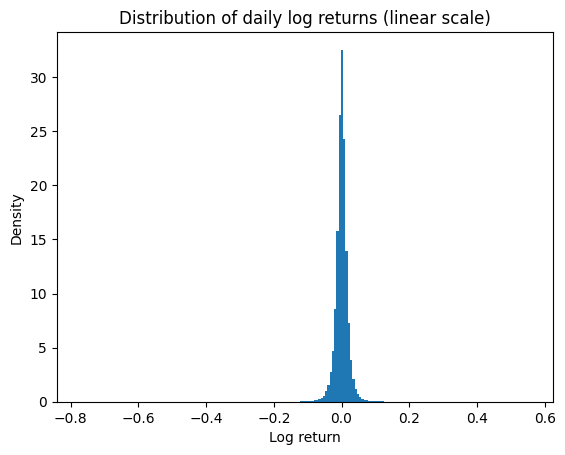

In [8]:
import matplotlib.pyplot as plt

returns = df["log_return"]

plt.hist(returns, bins=200, density=True)
plt.xlabel("Log return")
plt.ylabel("Density")
plt.title("Distribution of daily log returns (linear scale)")
plt.show()


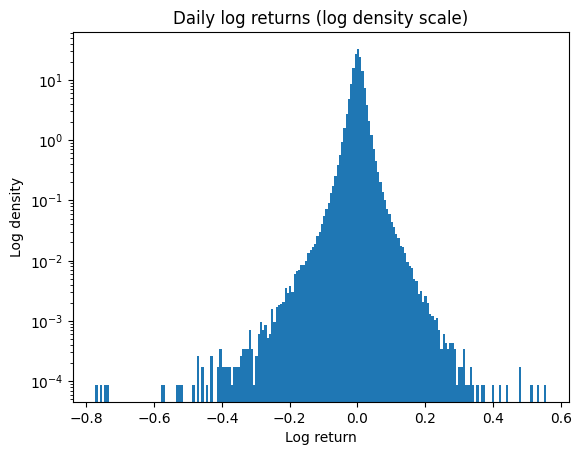

In [9]:
plt.hist(returns, bins=200, density=True)
plt.yscale("log")
plt.xlabel("Log return")
plt.ylabel("Log density")
plt.title("Daily log returns (log density scale)")
plt.show()


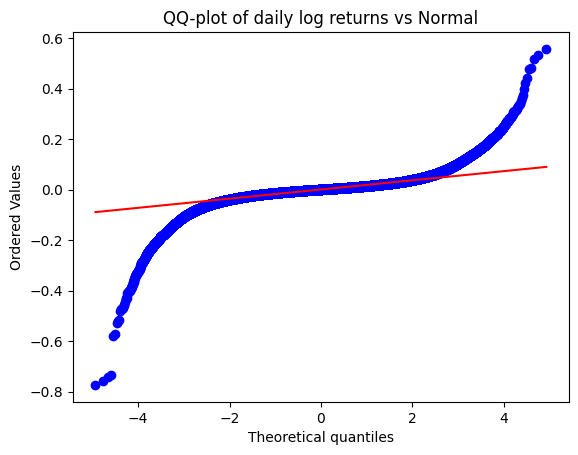

In [10]:
import scipy.stats as stats

stats.probplot(returns, dist="norm", plot=plt)
plt.title("QQ-plot of daily log returns vs Normal")
plt.show()


We overlay with a normal to see how it fits

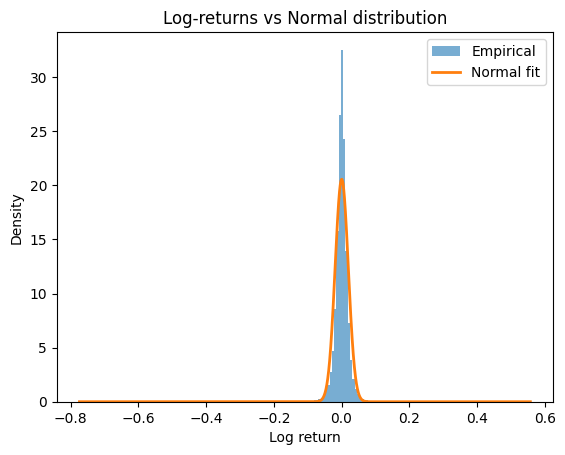

In [11]:
returns = df["log_return"].dropna()

mu = returns.mean()
sigma = returns.std()

x = np.linspace(returns.min(), returns.max(), 2000)

plt.hist(returns, bins=200, density=True, alpha=0.6, label="Empirical")
plt.plot(x, norm.pdf(x, mu, sigma), lw=2, label="Normal fit")

plt.xlabel("Log return")
plt.ylabel("Density")
plt.title("Log-returns vs Normal distribution")
plt.legend()
plt.show()

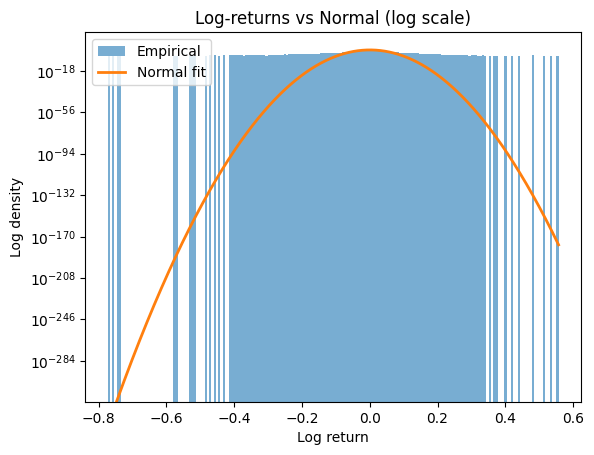

In [12]:

plt.hist(returns, bins=200, density=True, alpha=0.6, label="Empirical")
plt.plot(x, norm.pdf(x, mu, sigma), lw=2, label="Normal fit")

plt.yscale("log")
plt.xlabel("Log return")
plt.ylabel("Log density")
plt.title("Log-returns vs Normal (log scale)")
plt.legend()
plt.show()

My visualization fails because the normal is going way down in really low values... And the log scale follows

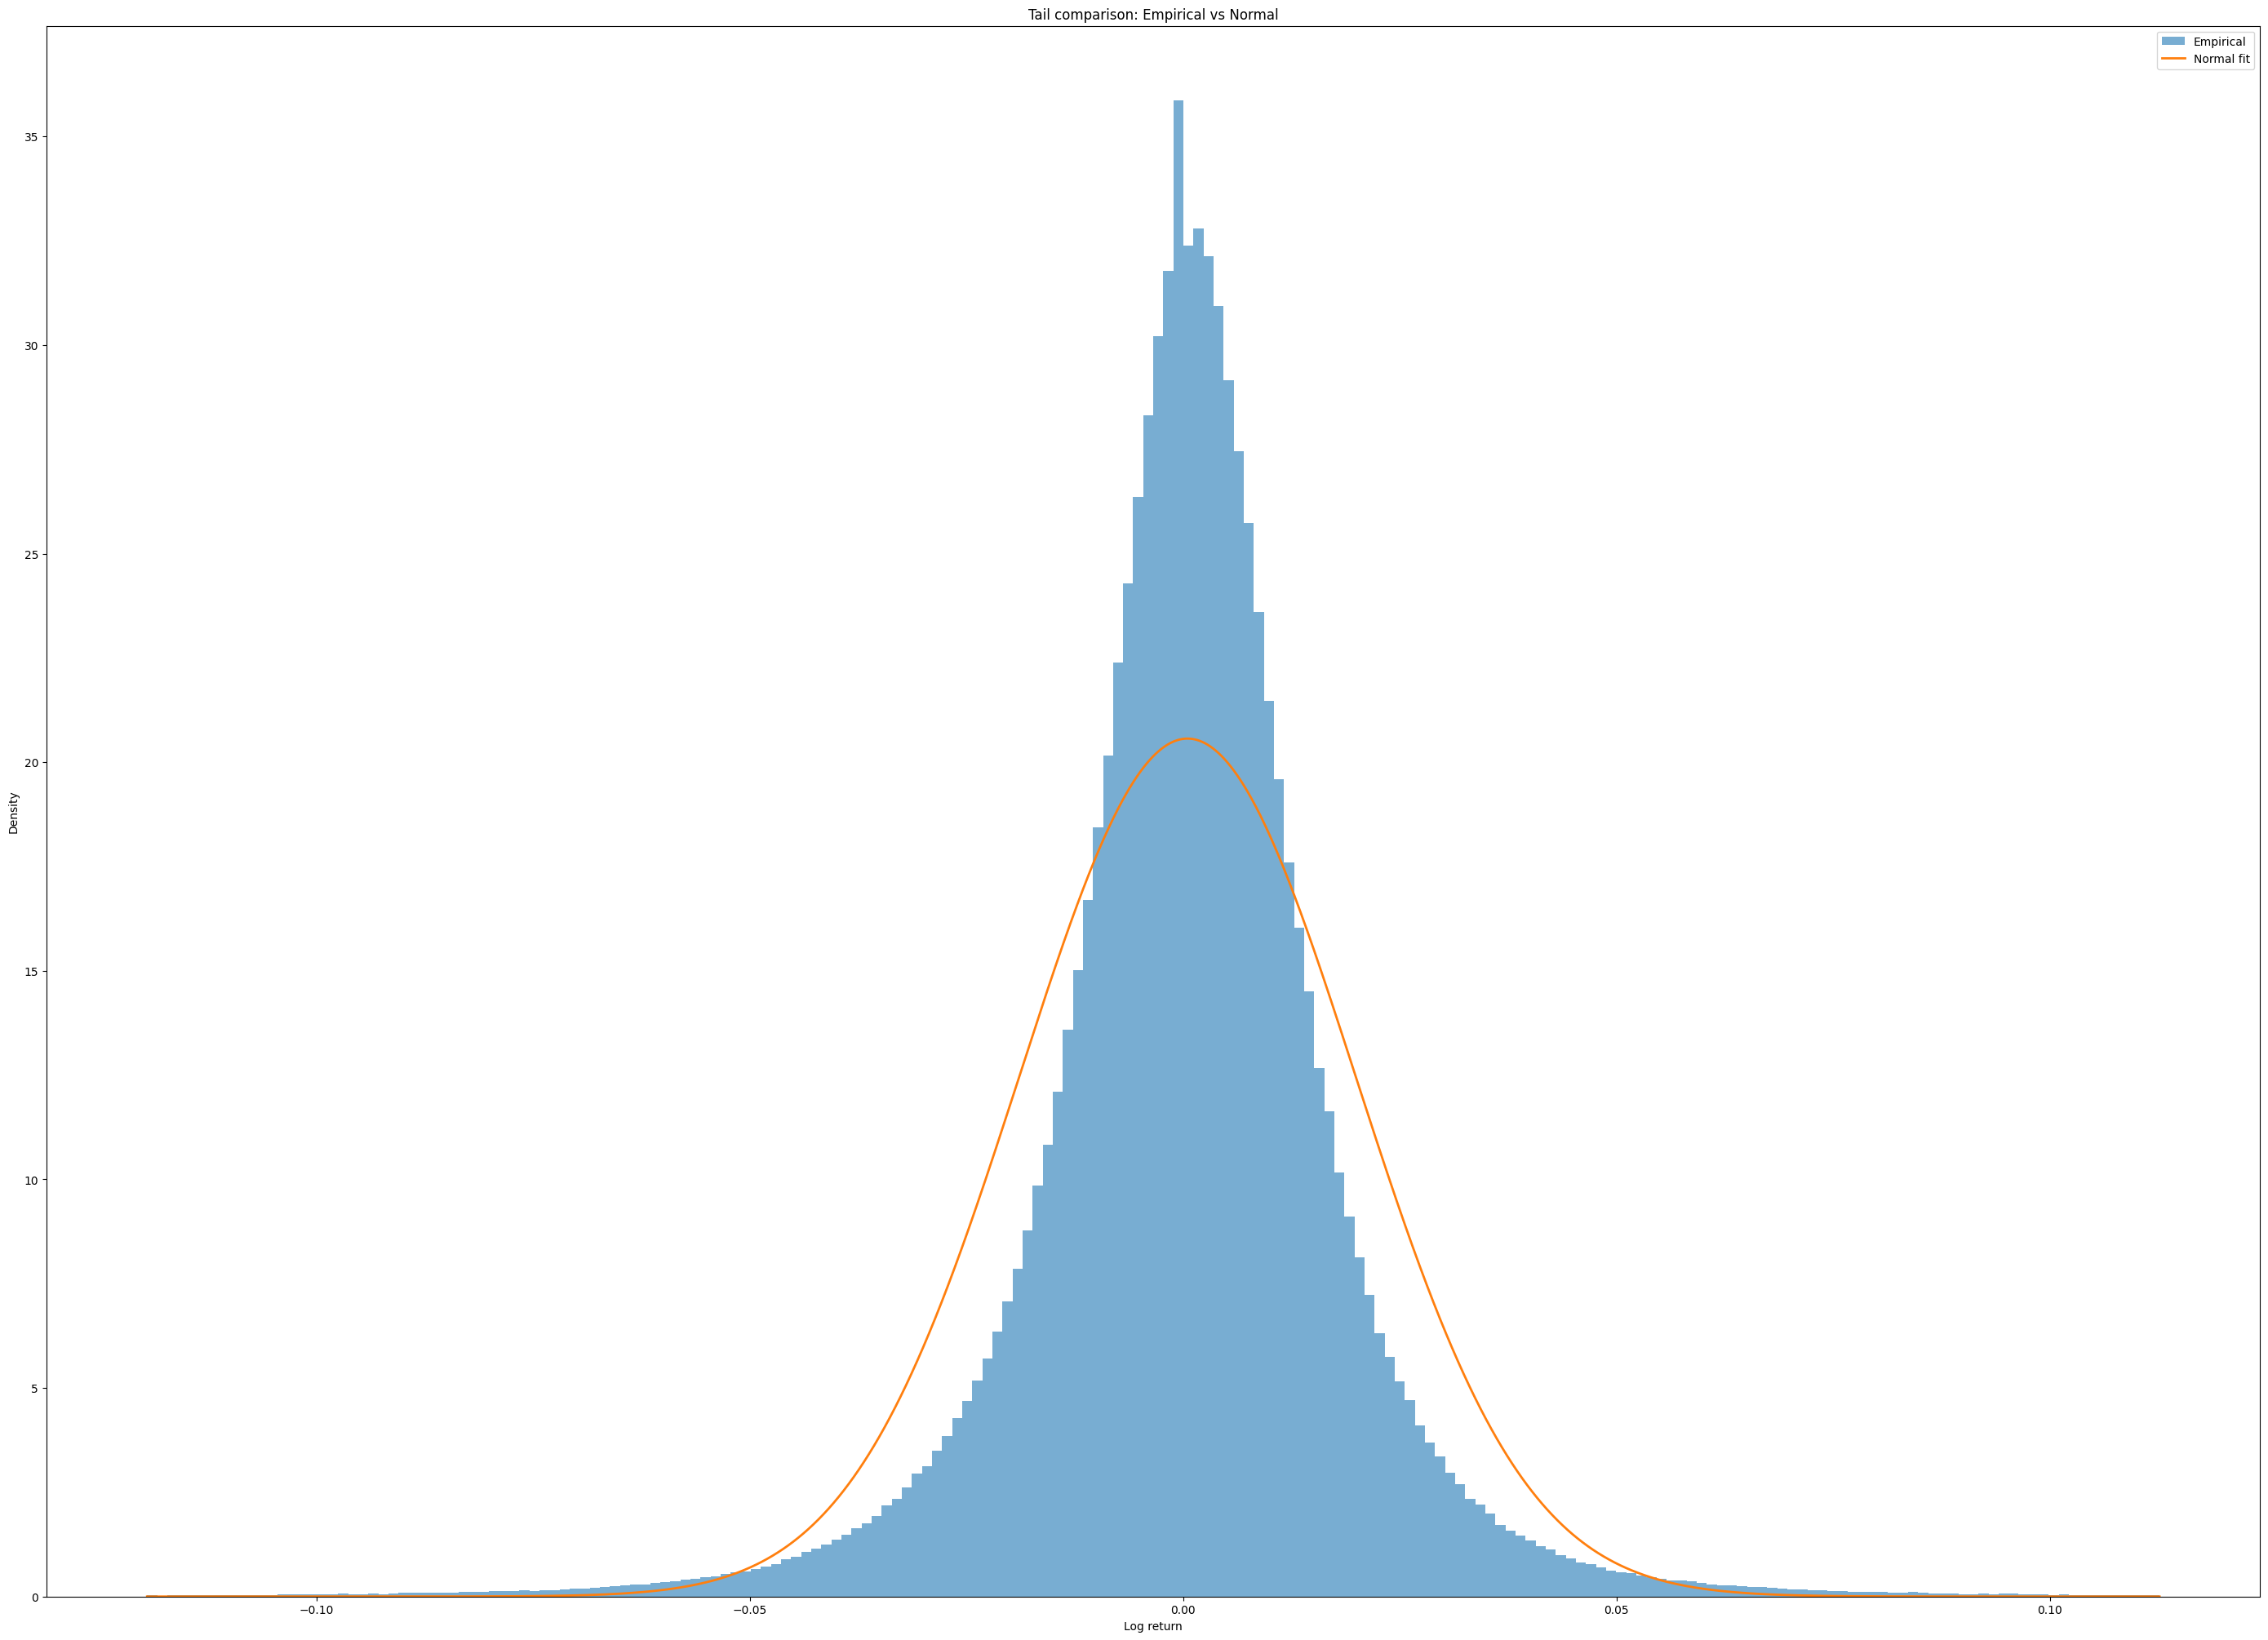

In [13]:
q_low, q_high = returns.quantile([0.001, 0.999])
q_low, q_high

x = np.linspace(q_low, q_high, 10000)
plt.figure(figsize=(35,25))
plt.hist(
    returns,
    bins=200,
    density=True,
    alpha=0.6,
    range=(q_low, q_high),
    label="Empirical"
)

plt.plot(x, norm.pdf(x, mu, sigma), lw=2, label="Normal fit")

plt.xlabel("Log return")
plt.ylabel("Density")
plt.title("Tail comparison: Empirical vs Normal")
plt.legend()

plt.show()

Now I will quantify the fat tails. First with Jarque-Bera and then with a simple ration of the empirical distribution over the normal.

In [14]:
from scipy.stats import jarque_bera

log_returns = df["log_return"].dropna()

jb_stat, jb_p = jarque_bera(log_returns)

print(f"JB statistic: {jb_stat:.2f}")
print(f"p-value: {jb_p:.2e}")


JB statistic: 57038360.76
p-value: 0.00e+00


In [15]:

q_emp = np.quantile(log_returns, [0.01, 0.05, 0.95, 0.99])
mu, sigma = log_returns.mean(), log_returns.std()

q_norm = norm.ppf([0.01, 0.05, 0.95, 0.99], mu, sigma)

tail_df = pd.DataFrame({
    "Empirical": q_emp,
    "Normal": q_norm,
    "Ratio": q_emp / q_norm
}, index=["1%", "5%", "95%", "99%"])

tail_df


,Empirical,Normal,Ratio
1%,-0.053467,-0.044620,1.198275
5%,-0.027709,-0.031400,0.882456
95%,0.027637,0.032415,0.852601
99%,0.052166,0.045635,1.143108


Now, I already did a skewness test (which is negative so leaning on the right with long tail on left) but I would like to now how the two tails differ.

In [16]:
# I try with the 1 percentile
q_low  = np.quantile(log_returns, 0.01)
q_high = np.quantile(log_returns, 0.99)

abs_ratio = abs(q_low) / abs(q_high)

print(q_low, q_high, abs_ratio)


-0.05346684464514487 0.05216586879076374 1.02493921570825


ratio ≈ 1 → symmetric tails

ratio > 1 → left tail heavier

ratio < 1 → right tail heavier


In [17]:
# more systematic

levels = [0.001, 0.005, 0.01, 0.05]

tail_asym = []

for p in levels:
    q_l = np.quantile(log_returns, p)
    q_u = np.quantile(log_returns, 1 - p)
    tail_asym.append({
        "p": p,
        "left": q_l,
        "right": q_u,
        "abs_ratio": abs(q_l) / abs(q_u)
    })

pd.DataFrame(tail_asym)


,p,left,right,abs_ratio
0,0.001,-0.119544,0.112667,1.061034
1,0.005,-0.068532,0.066691,1.027595
2,0.010,-0.053467,0.052166,1.024939
3,0.050,-0.027709,0.027637,1.002599


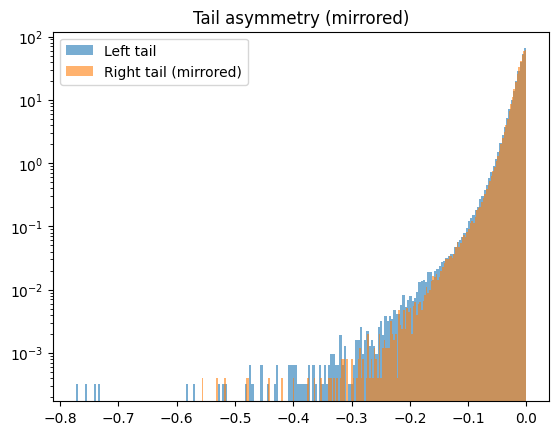

In [18]:
plt.hist(log_returns[log_returns < 0], bins=200, density=True, alpha=0.6, label="Left tail")
plt.hist(-log_returns[log_returns > 0], bins=200, density=True, alpha=0.6, label="Right tail (mirrored)")
plt.yscale("log")
plt.legend()
plt.title("Tail asymmetry (mirrored)")
plt.show()


Btw, the graph is in density mode, that's why it goes down to 10-3.

Now, I nee to check what are these outliers.

I could make a top 10 smallest returns and top 10 highest.

In [19]:
worst_10 = (
    df
    .sort_values(by="log_return", ascending=True)
    .head(10)
)

worst_10


,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,previous_adj_close,arithmetic_return,arithmetic_return_%,log_return
1085894,2020-03-09,APA,13.420000,13.700000,9.320000,9.550000,8.224354,28073200.0,17.826614,-0.538647,-53.864746,-0.773593
1522760,2024-04-11,GL,98.480003,98.580002,38.950001,49.169998,48.298512,36577500.0,103.070229,-0.531402,-53.140192,-0.758010
963624,2019-01-14,PCG,9.210000,9.730000,7.780000,8.380000,8.260254,127198800.0,17.338648,-0.523593,-52.359296,-0.741483
1086157,2020-03-09,OXY,15.580000,19.190001,12.040000,12.510000,11.708246,104930300.0,24.399191,-0.520138,-52.013793,-0.734257
1687685,2025-10-29,FISV,71.360001,76.650002,66.580002,70.599998,70.599998,103454200.0,126.169998,-0.440438,-44.043751,-0.580600
466345,2014-05-16,TKO,10.550000,11.930000,10.550000,11.270000,9.194171,40965100.0,16.259081,-0.434521,-43.452087,-0.570082
934838,2018-10-04,SMCI,1.516000,1.516000,0.850000,1.260000,1.260000,125601000.0,2.140000,-0.411215,-41.121499,-0.529694
1553665,2024-07-26,DXCM,66.000000,67.440002,62.340000,64.000000,64.000000,53914100.0,107.849998,-0.406583,-40.658321,-0.521858
1652415,2025-07-02,CNC,37.340000,37.779999,33.759998,33.779999,33.779999,93566700.0,56.650002,-0.403707,-40.370701,-0.517023
1612462,2025-02-13,WST,243.839996,249.410004,197.009995,199.110001,198.409729,5219500.0,321.146515,-0.382183,-38.218315,-0.481563


In [20]:
best_10 = (
    df
    .sort_values(by="log_return", ascending=False)
    .head(10)
)

best_10


,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,previous_adj_close,arithmetic_return,arithmetic_return_%,log_return
966592,2019-01-24,PCG,7.900000,14.500000,7.300000,13.950000,13.750663,82538300.0,7.875828,0.745932,74.593228,0.557289
1668775,2025-08-26,SATS,54.110001,55.189999,50.619999,50.869999,50.869999,46579100.0,29.879999,0.702477,70.247659,0.532084
562279,2015-04-13,BLDR,11.000000,11.740000,10.500000,11.570000,11.570000,17377500.0,6.900000,0.676812,67.681153,0.516894
351470,2013-04-19,VRTX,81.550003,85.900002,80.099998,85.599998,85.599998,24895000.0,52.869999,0.619066,61.906564,0.481849
693781,2016-07-05,DHR,68.634750,71.276596,68.563828,71.276596,67.867828,17648801.0,42.096821,0.612184,61.218418,0.477590
250558,2012-05-07,VRTX,52.119999,58.750000,51.849998,58.119999,58.119999,40216300.0,37.410000,0.553595,55.359527,0.440572
672486,2016-04-22,AMD,3.190000,3.990000,3.180000,3.990000,3.990000,143265300.0,2.620000,0.522901,52.290083,0.420617
1647999,2025-06-16,SATS,24.270000,25.290001,23.870001,25.110001,25.110001,15844900.0,16.840000,0.491093,49.109266,0.399509
347849,2013-04-09,FSLR,27.139999,41.000000,26.760000,39.349998,39.349998,40171200.0,27.040001,0.455251,45.525137,0.375179
1157147,2020-11-04,BIIB,253.199997,363.920013,251.750000,355.630005,355.630005,14591500.0,247.009995,0.439739,43.973933,0.364462


In [21]:
outliers = pd.concat(
    {
        "Worst returns": worst_10,
        "Best returns": best_10
    }
)

outliers


Date Ticker        Open        High         Low  \
Worst returns 1085894 2020-03-09    APA   13.420000   13.700000    9.320000   
              1522760 2024-04-11     GL   98.480003   98.580002   38.950001   
              963624  2019-01-14    PCG    9.210000    9.730000    7.780000   
              1086157 2020-03-09    OXY   15.580000   19.190001   12.040000   
              1687685 2025-10-29   FISV   71.360001   76.650002   66.580002   
              466345  2014-05-16    TKO   10.550000   11.930000   10.550000   
              934838  2018-10-04   SMCI    1.516000    1.516000    0.850000   
              1553665 2024-07-26   DXCM   66.000000   67.440002   62.340000   
              1652415 2025-07-02    CNC   37.340000   37.779999   33.759998   
              1612462 2025-02-13    WST  243.839996  249.410004  197.009995   
Best returns  966592  2019-01-24    PCG    7.900000   14.500000    7.300000   
              1668775 2025-08-26   SATS   54.110001   55.189999   50.619999   
              562279  2015-04-13   BLDR   11.000000   11.740000   10.500000   
              351470  2013-04-19   VRTX   81.550003   85.900002   80.099998   
              693781  2016-07-05    DHR   68.634750   71.276596   68.563828   
              250558  2012-05-07   VRTX   52.119999   58.750000   51.849998   
              672486  2016-04-22    AMD    3.190000    3.990000    3.180000   
              1647999 2025-06-16   SATS   24.270000   25.290001   23.870001   
              347849  2013-04-09   FSLR   27.139999   41.000000   26.760000   
              1157147 2020-11-04   BIIB  253.199997  363.920013  251.750000   

                            Close   Adj Close       Volume  \
Worst returns 1085894    9.550000    8.224354   28073200.0   
              1522760   49.169998   48.298512   36577500.0   
              963624     8.380000    8.260254  127198800.0   
              1086157   12.510000   11.708246  104930300.0   
              1687685   70.599998   70.599998  103454200.0   
              466345    11.270000    9.194171   40965100.0   
              934838     1.260000    1.260000  125601000.0   
              1553665   64.000000   64.000000   53914100.0   
              1652415   33.779999   33.779999   93566700.0   
              1612462  199.110001  198.409729    5219500.0   
Best returns  966592    13.950000   13.750663   82538300.0   
              1668775   50.869999   50.869999   46579100.0   
              562279    11.570000   11.570000   17377500.0   
              351470    85.599998   85.599998   24895000.0   
              693781    71.276596   67.867828   17648801.0   
              250558    58.119999   58.119999   40216300.0   
              672486     3.990000    3.990000  143265300.0   
              1647999   25.110001   25.110001   15844900.0   
              347849    39.349998   39.349998   40171200.0   
              1157147  355.630005  355.630005   14591500.0   

                       previous_adj_close  arithmetic_return  \
Worst returns 1085894           17.826614          -0.538647   
              1522760          103.070229          -0.531402   
              963624            17.338648          -0.523593   
              1086157           24.399191          -0.520138   
              1687685          126.169998          -0.440438   
              466345            16.259081          -0.434521   
              934838             2.140000          -0.411215   
              1553665          107.849998          -0.406583   
              1652415           56.650002          -0.403707   
              1612462          321.146515          -0.382183   
Best returns  966592             7.875828           0.745932   
              1668775           29.879999           0.702477   
              562279             6.900000           0.676812   
              351470            52.869999           0.619066   
              693781            42.096821           0.612184   
              250558            37.410000

I need to account for corporate actions.